# Mesh construction in PorePy
This tutorial describes how to use PorePy to create a mesh that conforms to a set of fractures without invoking PorePy's multiphysics simulation framework. The resulting mesh is accessible as a Gmsh .msh file which can be imported into other computational framework.

**Learning points**:
1. Read a set of line fractures from a .csv file into PorePy.
2. Use mesh size parameters to control the resolution of the resulting mesh. For more information on this, see the tutorial on 
<a href="https://github.com/pmgbergen/porepy/blob/develop/tutorials/mixed_dimensional_meshing.ipynb" target="_blank">mixed dimensional meshing</a>
in the PorePy repository.
3. Inspect the generated mesh.

DISCLAIMER: By not going through the multiphysics framework, which is the standard entrypoint for PorePy users, we will be exposed to some of the rougher edges of the software. This may for instance increase the likelihood of encountering incomplete documentation and somewhat opaque error messages (to be clear, using the multiphysics framework is no guarantee against such messages). Still, avoiding the multiphysics framework also means we get away with much less boilerplate code, so it may be worthwhile for certain use cases.


# Importing fracture networks specified in CSV files
We start by importing PorePy, as well as the Path class from pathlib. We then print the documentation of the function used to import fracture networks from csv:

In [1]:
import porepy as pp
from pathlib import Path

# Print the docstring for the function to check the arguments
pp.fracture_importer.network_from_csv?

Signature:
pp.fracture_importer.network_from_csv(
    file_name: 'Path',
    has_domain: 'bool' = True,
    tol: 'float' = 0.0001,
    **kwargs,
) -> 'FractureNetwork2d | FractureNetwork3d'
Docstring:
Create the fracture network from a CSV file.

The file is assumed to have the following structure:
- If has_domain is True, the first line describes the domain as a cuboid with
    ``X_MIN, Y_MIN, Z_MIN, X_MAX, Y_MAX, Z_MAX`` for 3D or ``X_MIN, Y_MIN,
    X_MAX, Y_MAX`` for 2D.
- In 2D, the remaining lines describe the fractures as a list of points (one line
    per fracture) ``START_X, START_Y, END_X, END_Y``.
- In 3D, Polygonal fractures are described as a list of points (one line per
    fracture) ``P0_X, P0_Y, P0_Z, ..., PN_X, PN_Y, PN_Z``.
    Elliptic fractures are described as ``CENTER_X, CENTER_Y, CENTER_Z,
    MAJOR_AXIS, MINOR_AXIS, MAJOR_AXIS_ANGLE, STRIKE_ANGLE, DIP_ANGLE``.
Lines starting with ``#`` will be ignored.

Parameters:
    file_name: Path to the CSV file.
    has_do

We will consider a 2d fracture network since this is easiest to work with in terms of visualization and computational effort. It is important to be aware that depending on the number of fractures and the geometry of the fracture network, the number of cells required to generate a decent mesh can be surprizingly high. Furthermore, when increasing the fracture count or geometrical complexity, the number of cells will grow much faster in 3d than in 2d.

In the data folder, there is a csv file with 30 fracture traces from an outcrop at the Western coast of Norway. This can be imported into a FractureNetwork object as follows:

In [2]:
network = pp.fracture_importer.network_from_csv(Path('Algeroyna.csv'))
# We can print the network to get an overview of the fractures included, as well as the domain (bounding box) of the network.
print(network)

Two-dimensional fracture network with 30 line fractures.
The domain is a rectangle with bounding box: {'xmin': np.float64(-54900.0), 'xmax': np.float64(-52000.0), 'ymin': np.float64(6730000.0), 'ymax': np.float64(6733000.0)}.


# Mesh generation
The next goal is to generate a mesh that conforms to this fracture network. To that end, we will invoke the mesh function of the fracture network. This takes as a mandatory argument a set of mesh size parameters as illustrated below. The effect of these arguments on the resulting mesh is explored in PorePy's tutorial on mixed-dimensional meshing and we refer to that for more information (note that said tutorial uses the multiphysics framework where some of the mesh size arguments have different names from those used below, however the translation should be straightforward).

In addition to setting the mesh size, we will also specify the name of the resulting gmsh file containing the mesh and ask gmsh to use parallel processing for meshing.

In [3]:
file_name = Path("algeroyna_mesh.msh")

# Absorb the generated mesh into the object mdg.
mdg = network.mesh(
    {"mesh_size_fracture": 60,
     "mesh_size_boundary": 100,
     "mesh_size_min": 20, 
     "refinement_size_multiplier": 0.9,
     "background_transition_multiplier": 15,
     "refinement_proximity_multiplier": 1.2
    },
    file_name=file_name,
    num_processors=4,  # This asks Gmsh to use 4 processors for the meshing (if available). 
)
# Print information on the grid:
print(mdg)


Mixed-dimensional grid. 
Maximum dimension present: 2 
Minimum dimension present: 0 
Size of highest dimensional grid: Cells: 11148. Nodes: 6224
In lower dimensions: 
30 grids of dimension 1, with in total 599 cells and 671 nodes. 
21 grids of dimension 0, with in total 21 cells and 0 nodes. 
Total number of interfaces: 72
30 interfaces between grids of dimension 2 and 1 with in total 1198 cells.
42 interfaces between grids of dimension 1 and 0 with in total 84 cells.



The printed information shows that rock matrix is tessalated by a 2d grid with 11K cells. In addition, there are 30 1d grids, one for each fractures, and 21 0d grids representing point intersections between fractures. There is also a number of interface grids, for more information on these, confer the PorePy's tutorial on subdomain and interface projections.


# Visualization
2d grids can be visualized directly in PorePy using a matplotlib backend. Please note that this method scales poorly with the number of cells, so it is not advisable to use this type of visualization for grids with significantly larger cell counts.

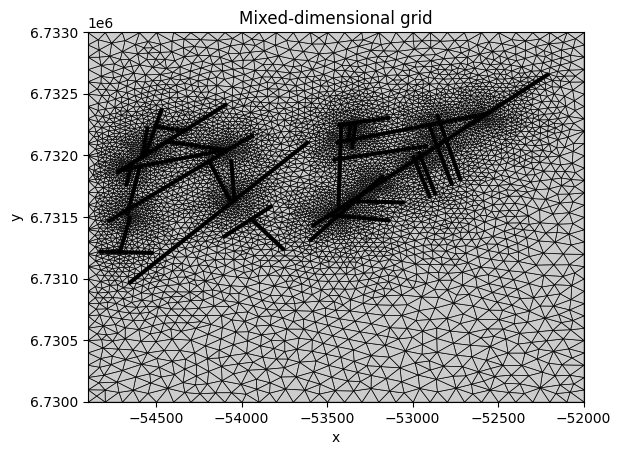

In [4]:
pp.plot_grid(
    mdg,
    figsize=(12, 10),
    plot_2d=True,
    fracturewidth_1d=3,
    linewidth=0.5,
    title="Mixed-dimensional grid",
    rgb=[0.8, 0.8, 0.8],
)

As is illustrated by the plot, and emphasized in PorePy's meshing tutorial, the mesh size control algorithm is designed to enable aggressive refinement towards fractures. It is also based on the premise that if the user has specified a complex fracture network geometry (e.g., proximate fractures, small angles), a high cell count may be the price to be paid. To strike a reasonable balance between mesh quality and computational cost may require some tweaking of the mesh size parameters, doing this takes practice. Also note that PorePy only uses a fraction of the mesh size control functionality in Gmsh, thus it is possible to manipulate mesh sizes directly in Gmsh before generating the mesh.

While plotting in matplotlib is convenient for simple cases, more advanced visualizations can be generated using Paraview. If we had used the multiphysics simulation framework, relevant data would have been exported automatically, but in our case, we need to explicitly generate an Exporter object and output vtu files.

In [5]:
exporter = pp.Exporter(mdg, file_name.with_suffix(".vtu"), folder_name=file_name.parent/ "algeroyna_visualization")
exporter.write_vtu()

This will result in a number of files being written to the subfolder algeroyna_visualization, among them a .pvd file that can be opened in Paraview. Zooming in on the left part of the fracture network gives the following picture:

<img src='mesh.png' width=900>


# Accessing the mesh in other computational platforms
Finally, the computational mesh can be accessed in other platforms in two ways:
1. Through the generated gmsh file, which should be available as 'algeroyna_mesh.msh'. Inspection of this file will show that cells on fractures and fracture intersection points can be identified through Gmsh's system of tags and physical names.
2. By importing the PorePy mesh directly. This is different from the Gmsh mesh, in that nodes and faces lying on fracture surfaces have been split so that there is one on each side of the fracture. The PorePy mesh can be saved to file, e.g., by using pickle.
